# LSTM Experiment 2

## Overview

The first LSTM experiment established a baseline deep learning model for burger sales forecasting.

Although the model successfully learned sequential data, its predictive performance was considerably lower than the LightGBM model.

This experiment introduces several improvements specifically designed for neural networks:

- MinMax feature scaling
- Separate scaling of the target variable
- Improved preprocessing pipeline
- Improved training strategy

The objective is to evaluate whether these modifications improve forecasting accuracy.

In [5]:
# ==========================================================
# Import Libraries
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import (
    MinMaxScaler,
    LabelEncoder
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


# Loading the Dataset

The cleaned dataset generated during the preprocessing stage is loaded.

All feature engineering completed in previous notebooks is preserved.

In [6]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("../data/burger_data_processed.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (24422, 21)


,Date,Region,Temperature,Humidity,Wind,Visibility,Pressure,Sales,Year,Month,...,DayOfWeek,Quarter,WeekOfYear,IsWeekend,Sales_Lag_1,Sales_Lag_7,Sales_Lag_30,Rolling_Mean_7,Rolling_Mean_30,Rolling_STD_7
0,2014-01-03,2,18.174600,0.435980,24.228756,13.744171,1016.652700,992.37,2014,1,...,4,1,1,0,204.32,699.35,1539.45,1581.357143,1639.600333,1291.820530
1,2014-01-04,1,21.861622,0.402545,11.281557,4.461844,1023.733652,23.83,2014,1,...,5,1,1,1,992.37,2774.98,2721.81,1623.217143,1621.364333,1262.900440
2,2014-01-04,8,3.776241,0.886265,5.661404,9.982186,1020.505489,672.21,2014,1,...,5,1,1,1,23.83,950.34,2240.22,1230.195714,1531.431667,1272.774252
3,2014-01-04,3,0.196468,0.829441,5.494188,8.846484,1024.717837,664.99,2014,1,...,5,1,1,1,672.21,405.83,468.78,1190.462857,1479.164667,1287.225940
4,2014-01-04,9,23.463183,0.724208,10.477588,11.057665,1010.657532,2765.08,2014,1,...,5,1,1,1,664.99,3087.19,137.76,1227.485714,1485.705000,1264.422258


# Convert Date Column

The Date column is converted into datetime format to preserve time-series information.

In [7]:
# ==========================================================
# Convert Date
# ==========================================================

df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24422 entries, 0 to 24421
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             24422 non-null  datetime64[ns]
 1   Region           24422 non-null  int64         
 2   Temperature      24422 non-null  float64       
 3   Humidity         24422 non-null  float64       
 4   Wind             24422 non-null  float64       
 5   Visibility       24422 non-null  float64       
 6   Pressure         24422 non-null  float64       
 7   Sales            24422 non-null  float64       
 8   Year             24422 non-null  int64         
 9   Month            24422 non-null  int64         
 10  Day              24422 non-null  int64         
 11  DayOfWeek        24422 non-null  int64         
 12  Quarter          24422 non-null  int64         
 13  WeekOfYear       24422 non-null  int64         
 14  IsWeekend        24422 non-null  int64

# Encode Region

The Region column contains categorical values.

Neural networks require numerical inputs, so the region labels are converted into integer values.

In [8]:
# ==========================================================
# Encode Region
# ==========================================================

encoder = LabelEncoder()

df["Region"] = encoder.fit_transform(df["Region"])

print(encoder.classes_)

[0 1 2 3 4 5 6 7 8 9]


# Feature Selection

The target variable is Sales.

The Date column is excluded from the feature matrix because temporal information has already been represented through engineered calendar features.

In [9]:
# ==========================================================
# Feature Selection
# ==========================================================

X = df.drop(
    columns=[
        "Sales",
        "Date"
    ]
)

y = df["Sales"]

print("Features:", X.shape)

print("Target:", y.shape)

Features: (24422, 19)
Target: (24422,)


# Train, Validation and Test Split

The dataset is divided chronologically to preserve the temporal order of observations.

Random shuffling is avoided because future observations should never influence model training.

In [10]:
# ==========================================================
# Chronological Split
# ==========================================================

train_size = int(len(df) * 0.70)

validation_size = int(len(df) * 0.15)

X_train = X.iloc[:train_size]

X_validation = X.iloc[
    train_size:
    train_size + validation_size
]

X_test = X.iloc[
    train_size + validation_size:
]

y_train = y.iloc[:train_size]

y_validation = y.iloc[
    train_size:
    train_size + validation_size
]

y_test = y.iloc[
    train_size + validation_size:
]

print("Training:", X_train.shape)
print("Validation:", X_validation.shape)
print("Testing:", X_test.shape)

Training: (17095, 19)
Validation: (3663, 19)
Testing: (3664, 19)


# Feature Scaling

Neural networks are highly sensitive to the scale of input data.

Unlike tree-based algorithms such as LightGBM, LSTMs perform better when all features lie within a similar numerical range.

In this experiment:

- A MinMaxScaler is used for the input features.
- A separate MinMaxScaler is used for the target variable (Sales).

Using separate scalers prevents information leakage while allowing predictions to be converted back to their original scale after training.

In [11]:
# ==========================================================
# Scale Features
# ==========================================================

from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)

X_validation_scaled = feature_scaler.transform(X_validation)

X_test_scaled = feature_scaler.transform(X_test)

print("Training:", X_train_scaled.shape)
print("Validation:", X_validation_scaled.shape)
print("Testing:", X_test_scaled.shape)

Training: (17095, 19)
Validation: (3663, 19)
Testing: (3664, 19)


# Scale the Target Variable

The target variable (Sales) is scaled independently.

Scaling the target improves optimization during neural network training and allows the model to learn more efficiently.

Predictions will later be transformed back into the original sales values.

In [12]:
# ==========================================================
# Scale Target Variable
# ==========================================================

target_scaler = MinMaxScaler()

y_train_scaled = target_scaler.fit_transform(
    y_train.values.reshape(-1,1)
)

y_validation_scaled = target_scaler.transform(
    y_validation.values.reshape(-1,1)
)

y_test_scaled = target_scaler.transform(
    y_test.values.reshape(-1,1)
)

print(y_train_scaled.shape)
print(y_validation_scaled.shape)
print(y_test_scaled.shape)

(17095, 1)
(3663, 1)
(3664, 1)


# Sequence Generation

LSTM models require sequential input rather than independent observations.

Each training sample consists of the previous 30 days of observations, while the target is the sales value immediately following that sequence.

In [13]:
# ==========================================================
# Create Sequences
# ==========================================================

def create_sequences(features, target, sequence_length=30):

    X_seq = []
    y_seq = []

    for i in range(sequence_length, len(features)):

        X_seq.append(features[i-sequence_length:i])

        y_seq.append(target[i])

    return np.array(X_seq), np.array(y_seq)

In [14]:
# ==========================================================
# Generate Sequences
# ==========================================================

sequence_length = 30

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    sequence_length
)

X_validation_seq, y_validation_seq = create_sequences(
    X_validation_scaled,
    y_validation_scaled,
    sequence_length
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    sequence_length
)

print("Training:", X_train_seq.shape)

print("Validation:", X_validation_seq.shape)

print("Testing:", X_test_seq.shape)

Training: (17065, 30, 19)
Validation: (3633, 30, 19)
Testing: (3634, 30, 19)


# Build the Improved LSTM Model

This experiment uses a deeper architecture than the baseline model.

The network consists of:

- Two stacked LSTM layers
- Dropout regularization
- Dense hidden layer
- Linear output neuron

This architecture is designed to better capture temporal relationships while reducing overfitting.

In [15]:
# ==========================================================
# Build Improved LSTM
# ==========================================================

model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(30, 19)),

    tf.keras.layers.LSTM(
        128,
        return_sequences=True
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.LSTM(64),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    tf.keras.layers.Dense(1)

])

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="mse",

    metrics=["mae"]

)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        75,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,297 (497.25 KB)

 Trainable params: 127,297 (497.25 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Improved LSTM

The model is trained using the scaled sequential data.

To improve generalization and reduce overfitting:

- EarlyStopping monitors the validation loss and restores the best weights.
- ReduceLROnPlateau lowers the learning rate whenever validation performance stops improving.

These callbacks help the model converge more efficiently while avoiding unnecessary training epochs.

In [16]:
# ==========================================================
# Training Callbacks
# ==========================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-6
)

In [17]:
# ==========================================================
# Train Model
# ==========================================================

history = model.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(
        X_validation_seq,
        y_validation_seq
    ),

    epochs=100,

    batch_size=32,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

print("Training Complete!")

Epoch 1/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - loss: 0.0999 - mae: 0.2775 - val_loss: 0.0913 - val_mae: 0.2696 - learning_rate: 0.0010
Epoch 2/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - loss: 0.0944 - mae: 0.2724 - val_loss: 0.0989 - val_mae: 0.2705 - learning_rate: 0.0010
Epoch 3/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 26s 49ms/step - loss: 0.0940 - mae: 0.2720 - val_loss: 0.0910 - val_mae: 0.2693 - learning_rate: 0.0010
Epoch 4/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - loss: 0.0928 - mae: 0.2703 - val_loss: 0.0908 - val_mae: 0.2689 - learning_rate: 0.0010
Epoch 5/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - loss: 0.0922 - mae: 0.2697 - val_loss: 0.0911 - val_mae: 0.2691 - learning_rate: 0.0010
Epoch 6/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 26s 49ms/step - loss: 0.0915 - mae: 0.2685 - val_loss: 0.0913 - val_mae: 0.2658 - learning_rate: 0.0010
Epoch 7/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - loss: 0.0913 - mae: 0.2680 - val_loss: 0.0901 - val_mae: 0.2653 - learnin

# Training History

The learning curves provide insight into how the model learns throughout training.

A decreasing training and validation loss indicates successful optimization, while diverging curves may suggest overfitting.

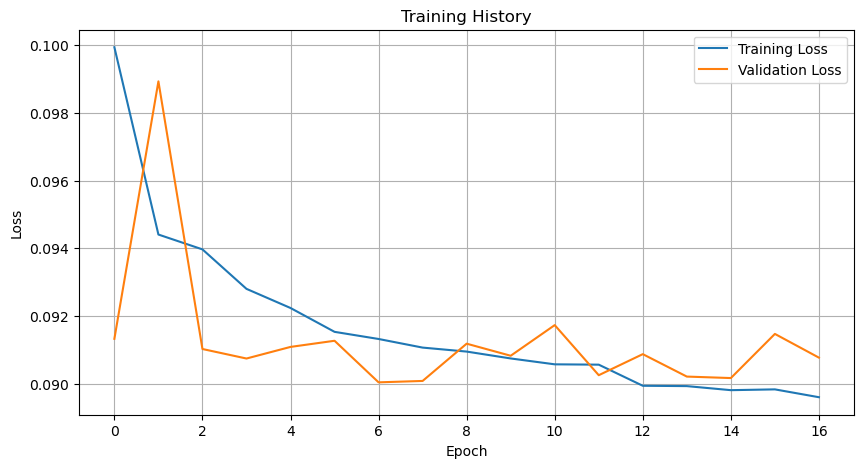

In [18]:
# ==========================================================
# Plot Training History
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training History")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

# Generate Predictions

Predictions are produced on the scaled target values.

The predictions are then transformed back to the original sales scale using the fitted target scaler, making evaluation metrics directly interpretable.

In [19]:
# ==========================================================
# Predictions
# ==========================================================

train_predictions = model.predict(X_train_seq)

validation_predictions = model.predict(X_validation_seq)

test_predictions = model.predict(X_test_seq)

534/534 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


In [20]:
# ==========================================================
# Inverse Transform Predictions
# ==========================================================

train_predictions = target_scaler.inverse_transform(train_predictions)

validation_predictions = target_scaler.inverse_transform(validation_predictions)

test_predictions = target_scaler.inverse_transform(test_predictions)

y_train_actual = target_scaler.inverse_transform(y_train_seq)

y_validation_actual = target_scaler.inverse_transform(y_validation_seq)

y_test_actual = target_scaler.inverse_transform(y_test_seq)

# Evaluation Metrics

The improved LSTM model is evaluated using several regression metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)
- Symmetric Mean Absolute Percentage Error (SMAPE)

These metrics provide a comprehensive assessment of forecasting accuracy.

In [21]:
# ==========================================================
# SMAPE
# ==========================================================

def smape(actual, predicted):

    actual = np.array(actual)

    predicted = np.array(predicted)

    denominator = (
        np.abs(actual)
        +
        np.abs(predicted)
    ) / 2

    return np.mean(
        np.abs(actual - predicted)
        /
        denominator
    ) * 100

In [22]:
# ==========================================================
# Evaluation Function
# ==========================================================

def evaluate(actual, predicted, dataset):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    r2 = r2_score(actual, predicted)

    smape_score = smape(
        actual,
        predicted
    )

    print("=" * 50)

    print(dataset)

    print("=" * 50)

    print(f"MAE   : {mae:.2f}")

    print(f"RMSE  : {rmse:.2f}")

    print(f"R²    : {r2:.4f}")

    print(f"SMAPE : {smape_score:.2f}%")

In [23]:
# ==========================================================
# Evaluate Model
# ==========================================================

evaluate(
    y_train_actual,
    train_predictions,
    "Training"
)

evaluate(
    y_validation_actual,
    validation_predictions,
    "Validation"
)

evaluate(
    y_test_actual,
    test_predictions,
    "Testing"
)

Training
MAE   : 945.88
RMSE  : 1069.59
R²    : 0.0310
SMAPE : 59.86%
Validation
MAE   : 945.58
RMSE  : 1069.58
R²    : 0.0180
SMAPE : 60.11%
Testing
MAE   : 954.69
RMSE  : 1082.29
R²    : 0.0124
SMAPE : 61.16%


# Actual vs Predicted Sales

A visual comparison between the observed and predicted sales values provides an intuitive assessment of the forecasting performance.

Ideally, the predicted values should closely follow the true sales trend over time.

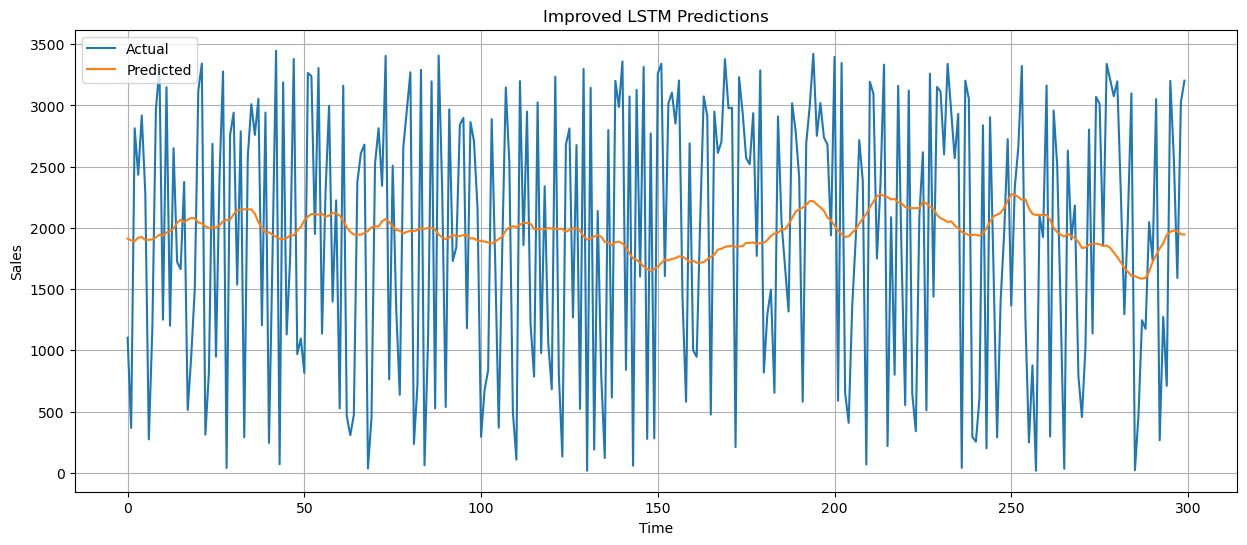

In [24]:
# ==========================================================
# Plot Predictions
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual[:300],
    label="Actual"
)

plt.plot(
    test_predictions[:300],
    label="Predicted"
)

plt.title("Improved LSTM Predictions")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()